# Pytorch Fundamentals

### **CONTENTS**

---


1. **Working with Tensors** (Scalars, Vectors, Matrices, Memory)
2. **Tensor Shape & Reshape** (Contiguous memory, Dims, Flattening)
3. **Tensor Operations** (Matrix Math, Reductions, Broadcasting)
4. **PyTorch Autograd** (DAGs, Chain Rule, Calculus)
5. **PyTorch nn.Module** (OOP Architecture, Parameters, Forward pass)
6. **PyTorch GPU Acceleration** (Device, cpu/cuda, VRAM)
7. **Model Training Checkpoints (saving training state)** (Serialization, Deserialization, State Dicts, Fault Tolerance)

### Import and Verify

In [ ]:
import torch

print(torch.__version__)

2.10.0+cpu


### Working with Tensors

In [ ]:
# Scalars (0D Values)
scalar = torch.tensor(0.29)
print(scalar)
print(scalar.shape)

# Vectors (1D Values)
vector = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5])
print(vector)
print(vector.shape)

# Matrices (2D Values)
matrix = torch.tensor([[0.1, 0.3, 0.4],
                        [0.5, 0.6, 0.3]])
print(matrix)
print(matrix.shape)

# Tensors (>2D Values)
# 3D
tensor3d = torch.tensor([[[3.2, 1.1], [2.1, 0.1], [4.1, 5.1]],
                        [[3.2, 1.1], [2.1, 0.1], [4.1, 5.1]]])
print(tensor3d)
print(tensor3d.shape)
# 4D
tensor4d = torch.rand(size=(2, 3, 5, 4))
print(tensor4d)
print(tensor4d.shape)


tensor(0.2900)
torch.Size([])
tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000])
torch.Size([5])
tensor([[0.1000, 0.3000, 0.4000],
        [0.5000, 0.6000, 0.3000]])
torch.Size([2, 3])
tensor([[[3.2000, 1.1000],
         [2.1000, 0.1000],
         [4.1000, 5.1000]],

        [[3.2000, 1.1000],
         [2.1000, 0.1000],
         [4.1000, 5.1000]]])
torch.Size([2, 3, 2])
tensor([[[[0.0845, 0.3752, 0.1731, 0.8479],
          [0.6556, 0.3103, 0.3945, 0.6525],
          [0.5540, 0.2975, 0.4334, 0.1562],
          [0.8198, 0.3545, 0.8796, 0.1415],
          [0.5373, 0.3611, 0.8495, 0.3765]],

         [[0.3210, 0.8210, 0.7296, 0.8235],
          [0.8766, 0.2367, 0.5553, 0.3478],
          [0.6734, 0.4125, 0.4490, 0.7566],
          [0.8018, 0.9580, 0.7917, 0.3745],
          [0.3584, 0.3833, 0.2241, 0.0476]],

         [[0.6002, 0.2232, 0.0653, 0.8278],
          [0.5055, 0.7207, 0.6318, 0.5933],
          [0.3753, 0.0268, 0.5561, 0.3178],
          [0.6270, 0.8174, 0.1516, 0.4611],
         

### Tesnsors Shape and Reshape

In [ ]:
# RESHAPE
# Sample 2D image for manipulation
img_2d = torch.rand(size=(28, 28))
# Original shape of the image
print(f"Original shape: {img_2d.shape}")
# Reshape using math 28 * 28 = 784 (2D to 1D flattening)
img_1d = img_2d.reshape(784)
print(f"Reshape using mathematics {img_1d.shape}")
# Reshape using "-1" inference
img_1dd = img_2d.reshape(-1)
print(f"Reshape using -1 inference: {img_1dd.shape}")

# UNSQUEEZE
# Sample single 3D image for manipulation (Channels, Height, Width)
sample_image = torch.rand(size=(3, 28, 28))
# Original shape of the image
print(f"Original shape: {sample_image.shape}")
# Unsqueeze image to increase 1 dimension (Batch, Channels, Height, Width)
batch_image = sample_image.unsqueeze(dim=0)
print(f"Batched image shape: {batch_image.shape}")
restore_image = batch_image.squeeze(dim=0)
print(f"Restored image shape: {restore_image.shape}")

# PERMUTE
# Sample image mimicing HWC format Indicies: 0 = Height, 1 = Width, 2 = Channels
hwc_image = torch.rand(size=(5, 5, 3))
print(f"HWC format image shape: {hwc_image.shape}")
# Permutation to Indicies: 0 = 2 (Channels), 1 = 0 (Height), 2 = 1 (Width)
chw_image = hwc_image.permute(2, 0, 1)
print(f"CHW format image shape: {chw_image.shape}")

Original shape: torch.Size([28, 28])
Reshape using mathematics torch.Size([784])
Reshape using -1 inference: torch.Size([784])
Original shape: torch.Size([3, 28, 28])
Batched image shape: torch.Size([1, 3, 28, 28])
Restored image shape: torch.Size([3, 28, 28])
HWC format image shape: torch.Size([5, 5, 3])
CHW format image shape: torch.Size([3, 5, 5])


### Tensor Operations

In [ ]:
# ELEMENT-WISE OPERATION
sample_img = torch.rand(size=(3, 4))
mask = torch.tensor([[1, 1, 1, 0],
                     [1, 1, 0, 0],
                     [1, 1, 1, 1]])

# Element-Wise multiplication (Hadamard Product)
masked_img = sample_img * mask
print(f"Hadamard Product:\n{masked_img}")

# Element-Wise subtraction
sample_img2 = torch.rand(size=(3, 4))
sub_img = sample_img - sample_img2
print(f"Element-Wise Subtraction:\n{sub_img}")

# TENSOR REDUCTION
# 1D batch of errors
batch_errors = torch.tensor([0.1, 0.2, 0.4, 0.6, 0.6, 0.3])
# Find the mean of the batch (1D) to reduce it to a single scalar value (0D) (mean)
batch_mean = torch.mean(batch_errors)
print(f"Batch mean:\n{batch_mean}")
# Dimension specific reduction
matrix_2d = torch.rand(size=(3, 4))
print(f"Original matrix:\n{matrix_2d}")
# Reduce the rows from the matrix (2D) to a vector of only columns (1D)
reduced_matrix = matrix_2d.mean(dim=0)
print(f"Reduced vector:\n{reduced_matrix}")

# MATRIX MULTIPLICATION (DOT PRODUCT)
# Matrix A (1 x 4)
A = torch.tensor([0.2, 0.4, 0.6, 0.8])
# Matrix B (4 x 3)
B = torch.rand(size=(4, 3))
print(f"Matrix A:\n{A}")
print(f"Matrix B:\n{B}")
# Dot product (row x column)
C = A @ B
print(f"Resultant matrix (dot product) (1 x 3):\n{C}")

# BROADCASTING
mat_zero = torch.zeros(size=(3, 4))
print(f"Zero matrix:\n{mat_zero}")
mat_mean = torch.rand(size=(1, 4))
print(f"Mean matrix:\n{mat_mean}")
mat_add = mat_zero + mat_mean
print(f"Broadcasted matrix:\n{mat_add}")

Hadamard Product:
tensor([[0.9943, 0.1211, 0.1055, 0.0000],
        [0.1843, 0.8490, 0.0000, 0.0000],
        [0.1816, 0.9805, 0.8700, 0.1802]])
Element-Wise Subtraction:
tensor([[ 0.7894, -0.8107, -0.2707,  0.1381],
        [ 0.0629,  0.5034,  0.0749, -0.5988],
        [-0.5167,  0.7571,  0.3818, -0.4561]])
Batch mean:
0.36666667461395264
Original matrix:
tensor([[0.3105, 0.9757, 0.6351, 0.6776],
        [0.2248, 0.7704, 0.1946, 0.8833],
        [0.0017, 0.5438, 0.7989, 0.1484]])
Reduced vector:
tensor([0.1790, 0.7633, 0.5429, 0.5698])
Matrix A:
tensor([0.2000, 0.4000, 0.6000, 0.8000])
Matrix B:
tensor([[0.6007, 0.8061, 0.0095],
        [0.6178, 0.7924, 0.1649],
        [0.4347, 0.6673, 0.8668],
        [0.5622, 0.0830, 0.1021]])
Resultant matrix (dot product) (1 x 3):
tensor([1.0779, 0.9450, 0.6697])
Zero matrix:
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
Mean matrix:
tensor([[0.4527, 0.1661, 0.7005, 0.8512]])
Broadcasted matrix:
tensor([[0.4527, 0

### PyTorch Autograd

#### PyTorch Autograd DAG pipeline

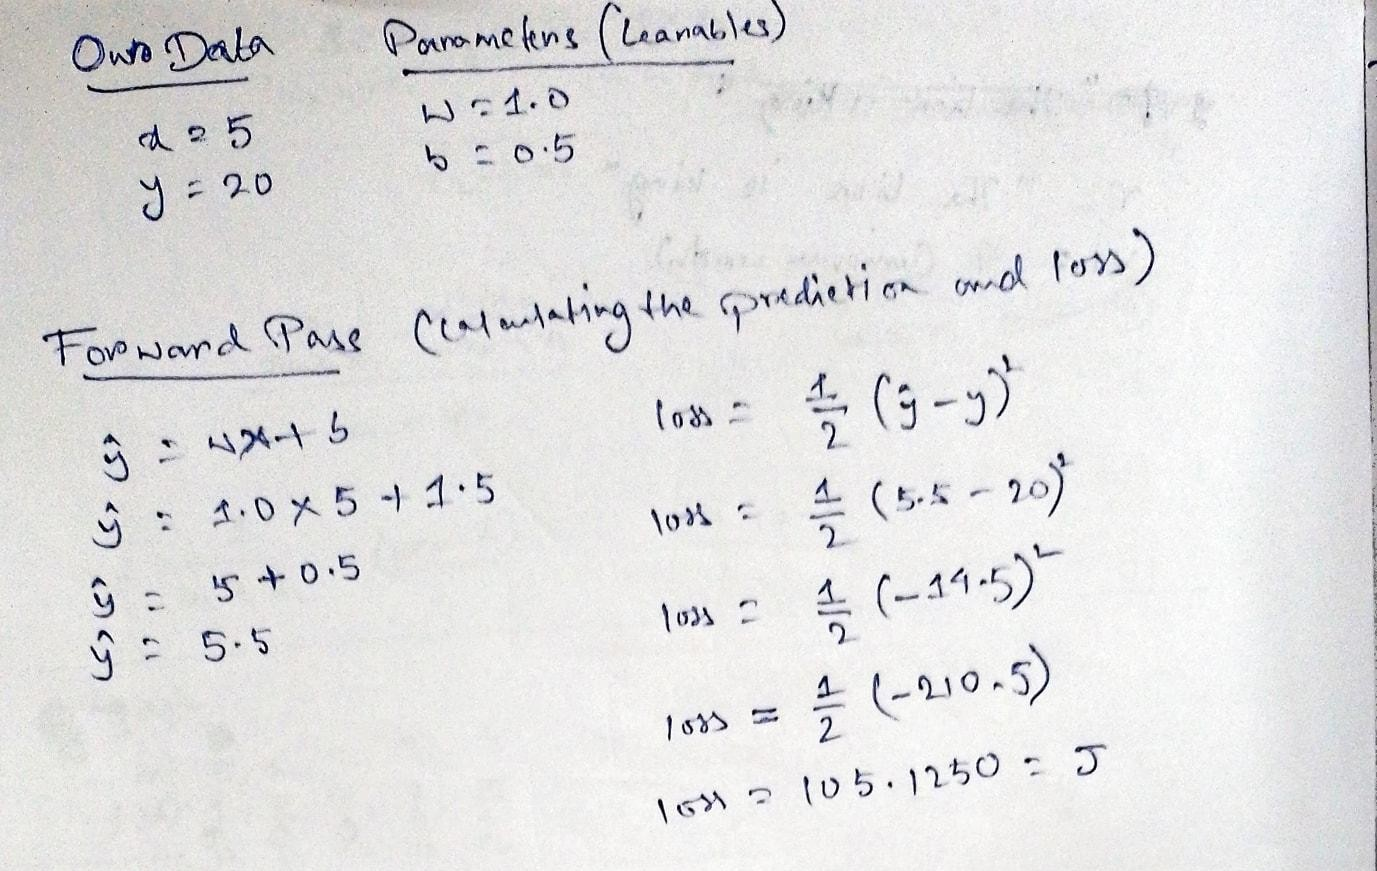

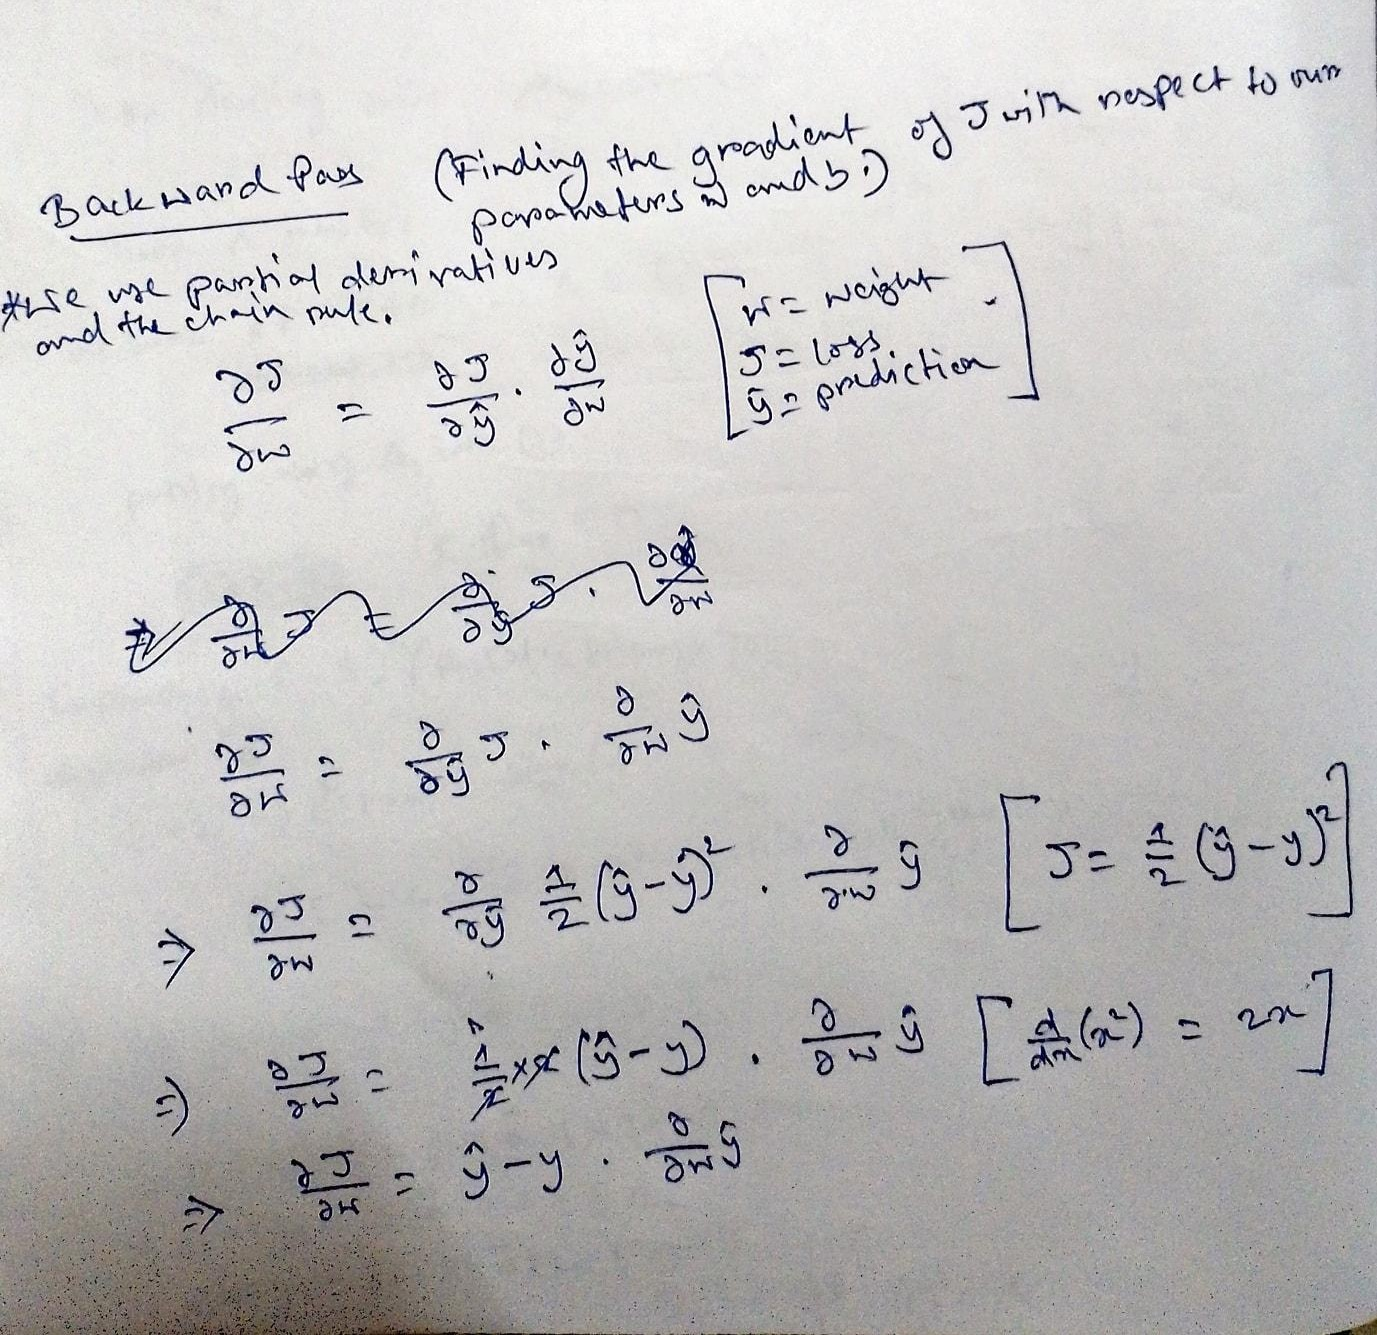

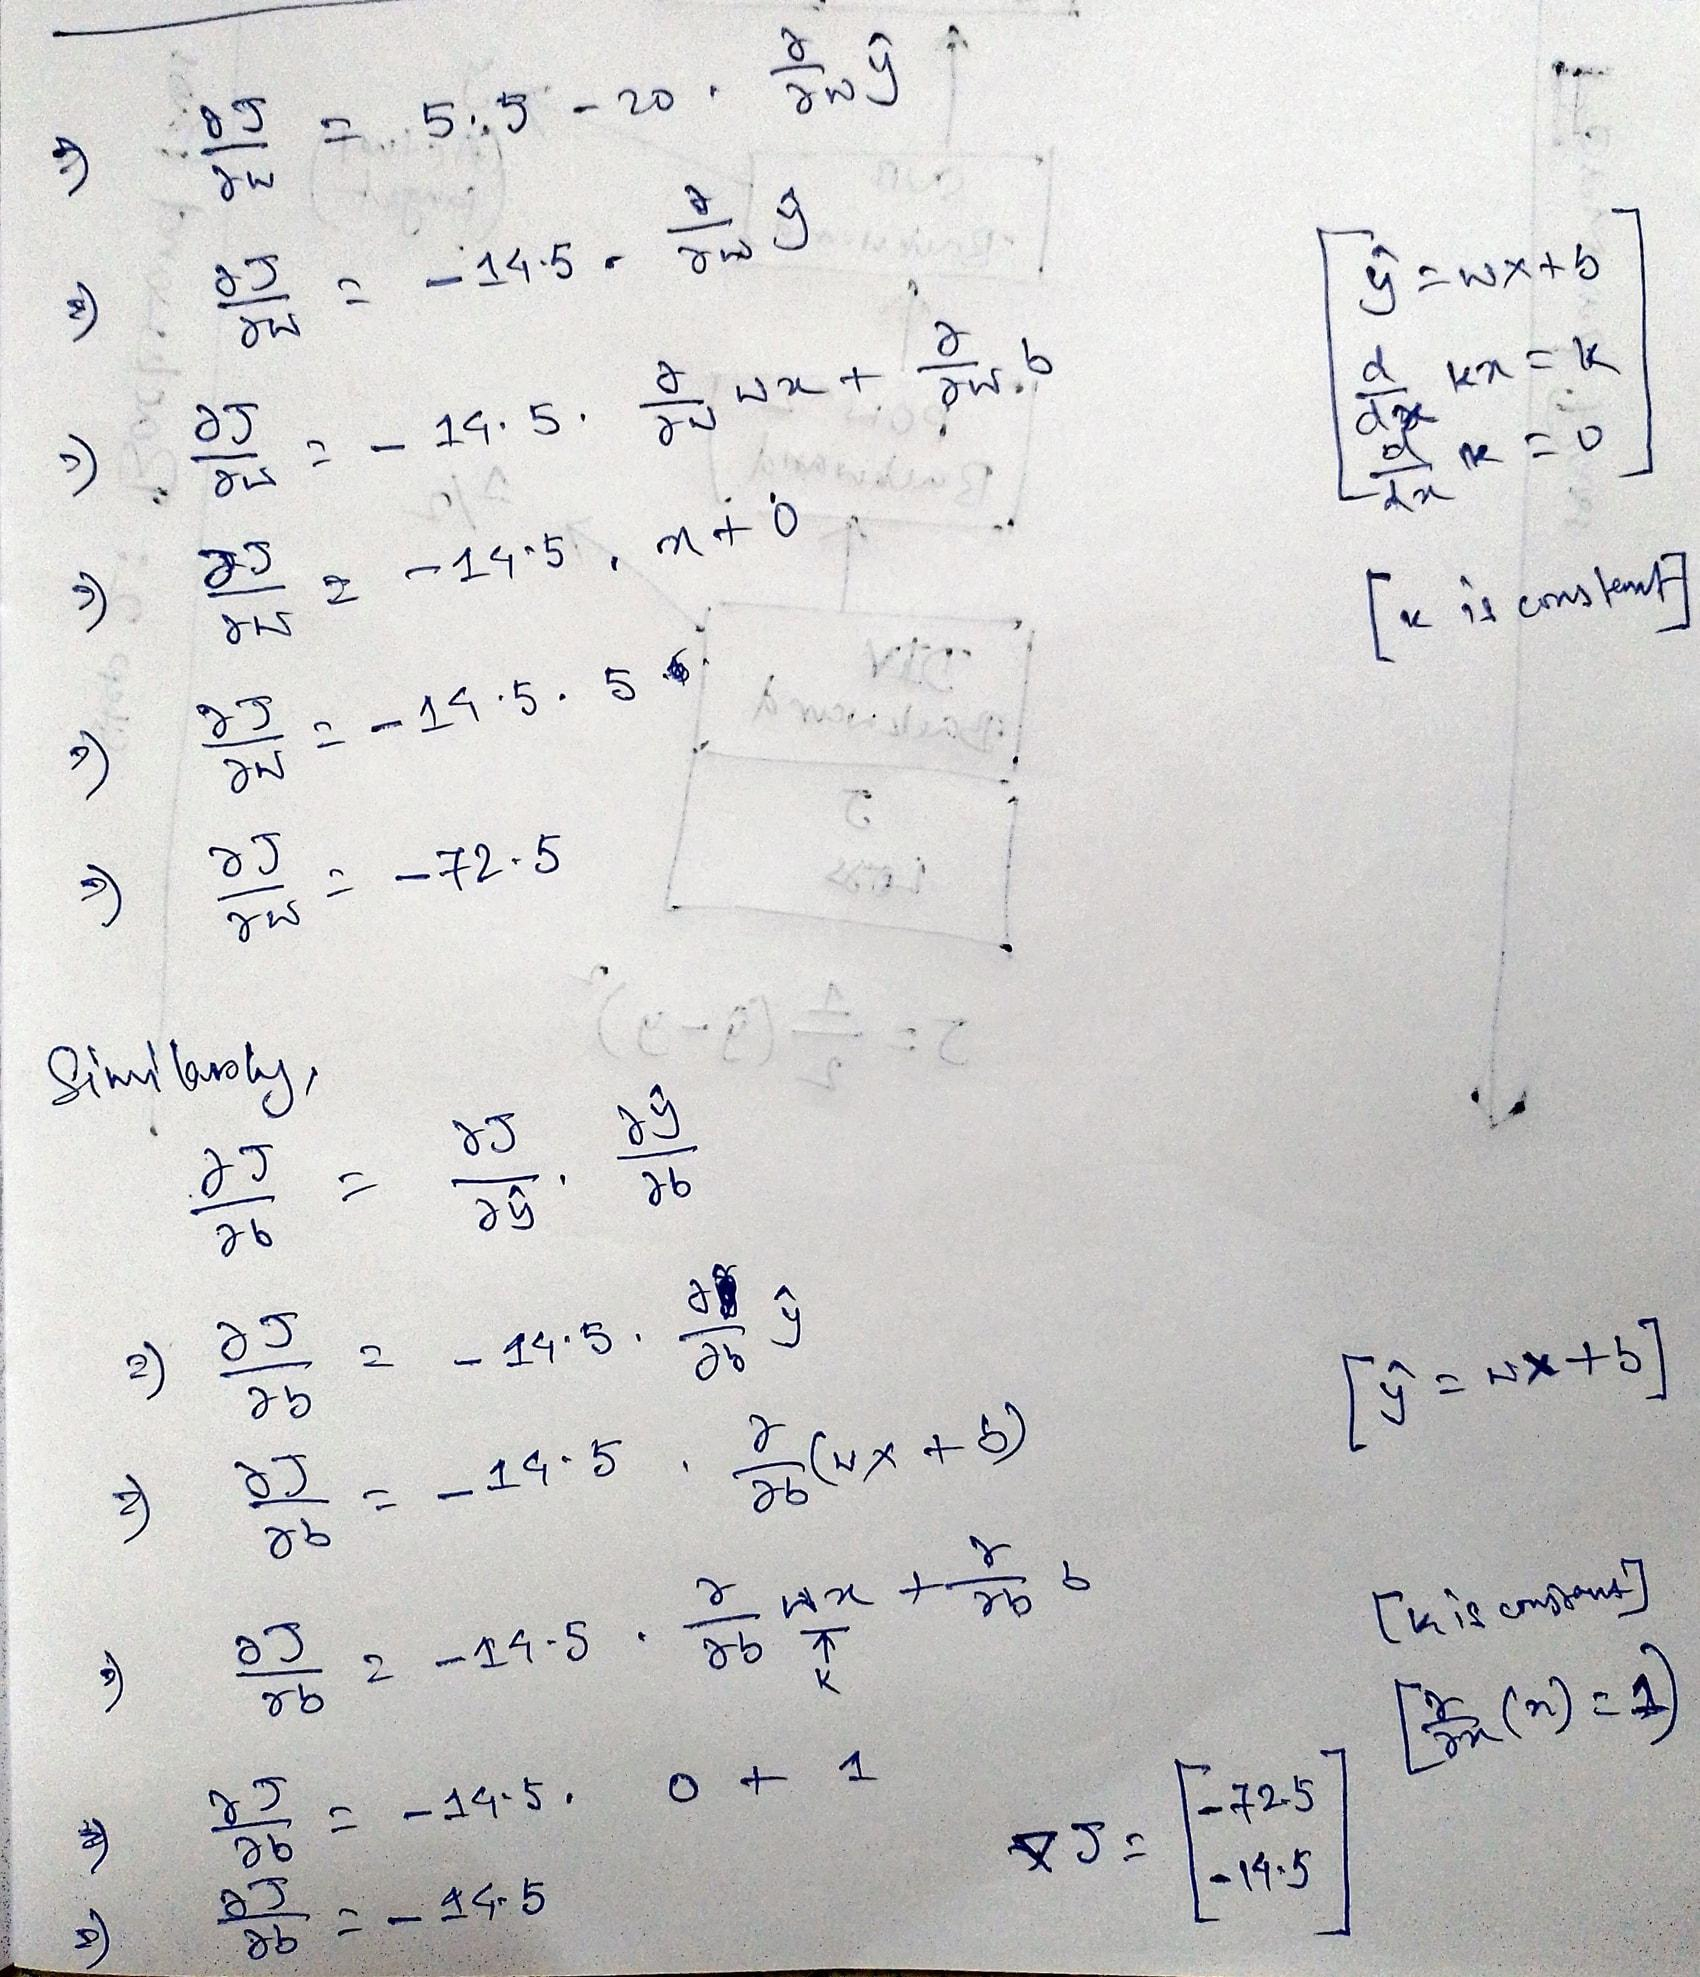

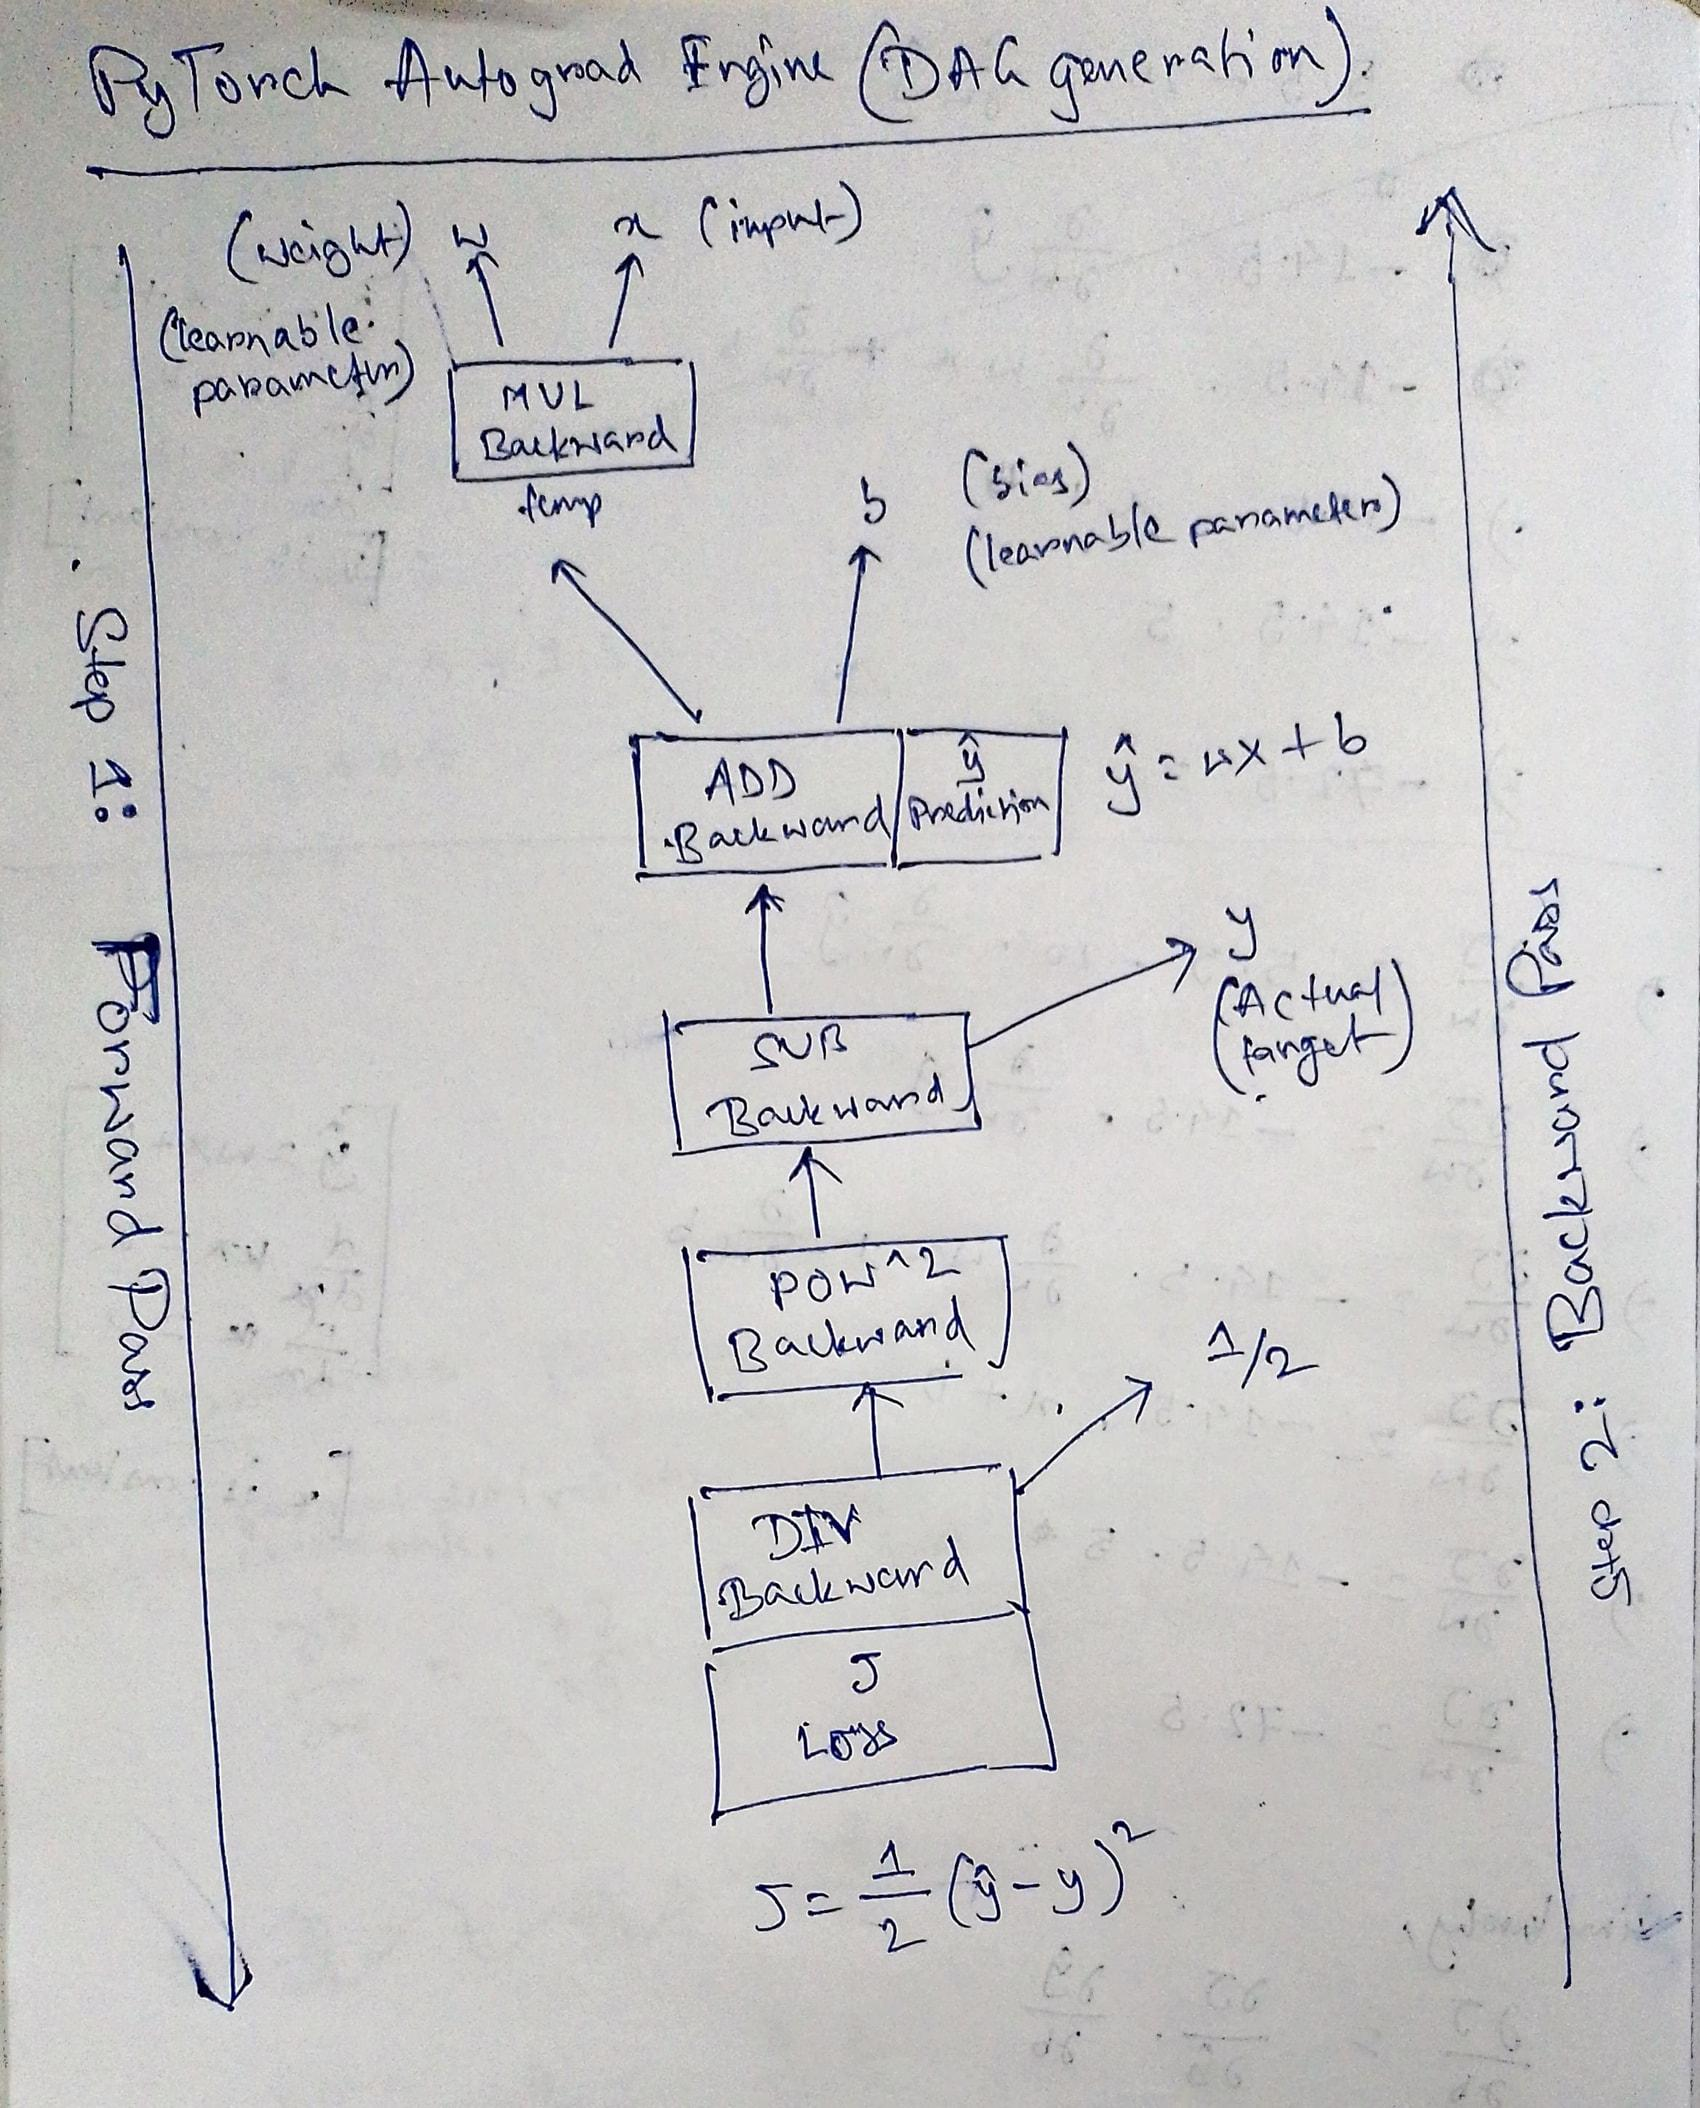

In [ ]:
""" PYTORCH GRADIENT DESCENT SINGLE EPOCH """
# Setting input feature and actual output
x = torch.tensor([5.0])
y = torch.tensor([20.0])
print(f"Input: {x}, Target: {y}")

# Setting the learnable parameters (Weight and Bias)
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True)
print(f"Weight: {w}, Track for DAG building (learning): {w.requires_grad}")
print(f"Weight: {b}, Track for DAG building (learning): {b.requires_grad}")

# USING THE AUTOGRAD ENGINE
# FORWARD PASS (Calculating the loss (J) and building the DAG backwards)
# Calculate the prediction (y')
prediction = w * x + b
print(f"Prediction tensor (y'):\n{prediction}")
# Calculate the loss (J)
loss = ((prediction - y)**2) / 2
print(f"Loss tensor (J):\n{loss}")

# BACKWARD PASS (Finding the gradients using the chain-rule by following the DAG to the parameters)
# Before backward pass
print(f"Gradient w (before backward pass): {w.grad}")
loss.backward()
# After backward pass
print(f"Gradient w (after backward pass): {w.grad}")
print(f"Gradient b (after backward pass): {b.grad}")

# OPTIMIZATION USING THE STORED GRADIANTS
# The learning rate at which the gradients will update for the learnable parameters (w and b)
learning_rate = 0.01
# Update the parameters (gradient descent)
# Temporarily disable the DAG engine
with torch.no_grad():
    # Subtract the gradients (update memory in-place)
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

    # Clear the gradient (.grad) memory block to 0 after update
    w.grad.zero_()
    b.grad.zero_()

print(f"Updated weight: {w}")
print(f"Updated bias: {b}")

Input: tensor([5.]), Target: tensor([20.])
Weight: 1.0, Track for DAG building (learning): True
Weight: 0.5, Track for DAG building (learning): True
Prediction tensor (y'):
tensor([5.5000], grad_fn=<AddBackward0>)
Loss tensor (J):
tensor([105.1250], grad_fn=<DivBackward0>)
Gradient w (before backward pass): None
Gradient w (after backward pass): -72.5
Gradient b (after backward pass): -14.5
Updated weight: 1.7249999046325684
Updated bias: 0.6449999809265137


In [ ]:
""" PYTORCH GRADIENT DESCENT MULTI-EPOCH """
# Input and output
x = torch.tensor([5.0])
y = torch.tensor([20.0])
print(f"Input: {x}, Target: {y}")

# Parameters (Weight and Bias)
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True)
print(f"Weight: {w}, Track for DAG building (learning): {w.requires_grad}")
print(f"Weight: {b}, Track for DAG building (learning): {b.requires_grad}")

# Learning configurations
learning_rate = 0.01
epochs = 200

# USING THE AUTOGRAD ENGINE
print("START THE TRAINING LOOP")
for epoch in range(epochs):
    # FORWARD PASS
    # Calculate the prediction (y')
    prediction = w * x + b

    # Calculate the loss (J)
    loss = ((prediction - y)**2) / 2

    # BACKWARD PASS
    loss.backward()

    # OPTIMIZATION
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

        w.grad.zero_()
        b.grad.zero_()

    if ((epoch + 1) % 20 == 0):
        print(f"Epoch: {epoch + 1:3d} | Loss: {loss.item():.6f} | Prediction: {prediction.item():.4f} | w: {w.item():.4f} | b: {b.item():.4f}")


print(f"Training Complete")
print(f"Final w: {w.item():.4f}, Final b: {b.item():.4f}")

correct_prediction = w * x + b
print(f"x: {x.item():.4f}, y: {y.item():.4f}, prediction: {correct_prediction.item():.4f}")

Input: tensor([5.]), Target: tensor([20.])
Weight: 1.0, Track for DAG building (learning): True
Weight: 0.5, Track for DAG building (learning): True
START THE TRAINING LOOP
Epoch:  20 | Loss: 0.001129 | Prediction: 19.9525 | w: 3.7817 | b: 1.0563
Epoch:  40 | Loss: 0.000000 | Prediction: 19.9999 | w: 3.7884 | b: 1.0577
Epoch:  60 | Loss: 0.000000 | Prediction: 20.0000 | w: 3.7885 | b: 1.0577
Epoch:  80 | Loss: 0.000000 | Prediction: 20.0000 | w: 3.7885 | b: 1.0577
Epoch: 100 | Loss: 0.000000 | Prediction: 20.0000 | w: 3.7885 | b: 1.0577
Epoch: 120 | Loss: 0.000000 | Prediction: 20.0000 | w: 3.7885 | b: 1.0577
Epoch: 140 | Loss: 0.000000 | Prediction: 20.0000 | w: 3.7885 | b: 1.0577
Epoch: 160 | Loss: 0.000000 | Prediction: 20.0000 | w: 3.7885 | b: 1.0577
Epoch: 180 | Loss: 0.000000 | Prediction: 20.0000 | w: 3.7885 | b: 1.0577
Epoch: 200 | Loss: 0.000000 | Prediction: 20.0000 | w: 3.7885 | b: 1.0577
Training Complete
Final w: 3.7885, Final b: 1.0577
x: 5.0000, y: 20.0000, prediction: 2

In [ ]:
""" PYTORCH MANUAL LINEAR REGRESSTION AND GRADIENT DESCENT USING A SAMPLE DATASET """

# Initializing the dataset of 3 entries with 3 features
X = torch.tensor([
    [1.0, 2.0, 1.0],    # Entry 0
    [2.0, 1.0, 3.0],    # Entry 1
    [3.0, 3.0, 2.0]     # Entry 2
])
print(f"Shape of features (X): {X.shape}")
# Target for each entries
Y = torch.tensor([[8.0],
                  [18.0],
                  [14.0]])
print(f"Shapre of targets (Y): {Y.shape}")
# Paramters: Weights for each features and the Bias
W = torch.tensor([[0.1],
                 [0.1],
                 [0.1]], requires_grad=True)
b = torch.tensor(0.1, requires_grad=True)

# Learning configurations
learning_rate = 0.01
epochs = 1000

# The training phase
print("START WITH THE TRAINING")
for epoch in range(epochs):
    # Forward Pass
    # Calculate the prediction
    # Prediction shape: X: (3, 3) @ W: (3, 1) (dot product) + broadcasted scaler b: (3, 1) = (3, 1)
    prediction = X @ W + b
    # Calculate the scalar loss
    loss = torch.mean((prediction - Y)**2)
    # Backward Pass (Populate W.grad and b.grad)
    loss.backward()
    # Optimization
    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad
        W.grad.zero_()
        b.grad.zero_()
    # Logging
    if ((epoch + 1) % 50 == 0):
        print(f"Epoch: {epoch + 1:4d} | Loss: {loss.item():.6f}")

# Post training
print("TRAINING COMPLETE")
print(f"Final learned weights:\n{W}")
print(f"Final learned bias: {b.item():.4f}")
final_prediciton = X @ W + b
for i in range(X.shape[0]):
    print(f"Test prediction: {i}: {final_prediciton[i].item():.4f} | Target: {Y[i].item()}")

Shape of features (X): torch.Size([3, 3])
Shapre of targets (Y): torch.Size([3, 1])
START WITH THE TRAINING
Epoch:   50 | Loss: 2.086135
Epoch:  100 | Loss: 0.614869
Epoch:  150 | Loss: 0.322758
Epoch:  200 | Loss: 0.214842
Epoch:  250 | Loss: 0.151193
Epoch:  300 | Loss: 0.107563
Epoch:  350 | Loss: 0.076680
Epoch:  400 | Loss: 0.054685
Epoch:  450 | Loss: 0.039002
Epoch:  500 | Loss: 0.027816
Epoch:  550 | Loss: 0.019839
Epoch:  600 | Loss: 0.014150
Epoch:  650 | Loss: 0.010092
Epoch:  700 | Loss: 0.007198
Epoch:  750 | Loss: 0.005133
Epoch:  800 | Loss: 0.003661
Epoch:  850 | Loss: 0.002611
Epoch:  900 | Loss: 0.001862
Epoch:  950 | Loss: 0.001328
Epoch: 1000 | Loss: 0.000947
TRAINING COMPLETE
Final learned weights:
tensor([[0.5446],
        [0.1584],
        [4.8251]], requires_grad=True)
Final learned bias: 2.2694
Test prediction: 0: 7.9560 | Target: 8.0
Test prediction: 1: 17.9924 | Target: 18.0
Test prediction: 2: 14.0288 | Target: 14.0


#### Quick Note on The Matrix Manipulation Above

##### 1. Matrix Multiplication (The Dot Product): `X @ W`

**The Rule:** To multiply matrices, we take the *rows* of the first matrix ($X$) and compute the sum of the products against the *columns* of the second matrix ($W$).

*   $X$ shape: `(3, 3)` — 3 rows, 3 columns.
*   $W$ shape: `(3, 1)` — 3 rows, 1 column.
*   Because the inner dimensions match ($3 = 3$), the operation is valid. The output shape will be the outer dimensions: `(3, 1)`.

**The Mathematical Execution:**

$$
\begin{bmatrix}
1.0 & 2.0 & 1.0 \\
2.0 & 1.0 & 3.0 \\
3.0 & 3.0 & 2.0
\end{bmatrix}
\times
\begin{bmatrix}
0.1 \\
0.1 \\
0.1
\end{bmatrix}
=
\begin{bmatrix}
(1.0 \times 0.1) + (2.0 \times 0.1) + (1.0 \times 0.1) \\
(2.0 \times 0.1) + (1.0 \times 0.1) + (3.0 \times 0.1) \\
(3.0 \times 0.1) + (3.0 \times 0.1) + (2.0 \times 0.1)
\end{bmatrix}
$$

**The Intermediate Result in RAM:**

$$
\text{temp} =
\begin{bmatrix}
0.1 + 0.2 + 0.1 \\
0.2 + 0.1 + 0.3 \\
0.3 + 0.3 + 0.2
\end{bmatrix}
=
\begin{bmatrix}
0.4 \\
0.6 \\
0.8
\end{bmatrix}
$$
*(This intermediate `(3, 1)` tensor holds the pure weighted sum of the features before the bias is added).*

---

##### 2. The Addition & Broadcasting: `+ b`

**The Rule:** Element-wise addition strictly requires identical shapes. We are trying to add a `(3, 1)` matrix and a `(0)` dimensional scalar ($0.1$).

To avoid crashing, the C++ backend intercepts this and triggers **Broadcasting**. It conceptually duplicates the scalar to match the `(3, 1)` matrix.

**The Mathematical Execution:**

$$
\begin{bmatrix}
0.4 \\
0.6 \\
0.8
\end{bmatrix}
+ 0.1
\xrightarrow{\text{Broadcasting}}
\begin{bmatrix}
0.4 \\
0.6 \\
0.8
\end{bmatrix}
+
\begin{bmatrix}
0.1 \\
0.1 \\
0.1
\end{bmatrix}
=
\begin{bmatrix}
0.5 \\
0.7 \\
0.9
\end{bmatrix}
$$

**The Result in RAM:**
The variable `prediction` is successfully populated as a `(3, 1)` tensor: `[[0.5], [0.7], [0.9]]`.

---

##### 3. The Error Calculation: `(prediction - Y)**2`

**The Rule:** `prediction` is `(3, 1)` and `Y` is `(3, 1)`. Because the shapes match perfectly, the computer executes standard element-wise subtraction, followed by element-wise squaring.

**The Mathematical Execution (Subtraction):**

$$
\begin{bmatrix}
0.5 \\
0.7 \\
0.9
\end{bmatrix}
-
\begin{bmatrix}
8.0 \\
18.0 \\
14.0
\end{bmatrix}
=
\begin{bmatrix}
-7.5 \\
-17.3 \\
-13.1
\end{bmatrix}
$$

**The Mathematical Execution (Squaring):**
The computer squares each negative value, turning them into large positive error penalties.

$$
\begin{bmatrix}
(-7.5)^2 \\
(-17.3)^2 \\
(-13.1)^2
\end{bmatrix}
=
\begin{bmatrix}
56.25 \\
299.29 \\
171.61
\end{bmatrix}
$$

---

##### 4. The Reduction: `torch.mean(...)`

**The Rule:** The `mean` function takes the multidimensional tensor and collapses it into a single scalar by adding all elements together and dividing by the total number of elements.

**The Mathematical Execution:**

$$
\text{Loss} = \frac{56.25 + 299.29 + 171.61}{3} = \frac{527.15}{3} \approx 175.7166
$$

**The Result in RAM:**
The `loss` variable becomes a `0`-dimensional scalar tensor containing the value `175.7166`.

Because every single one of these matrix transformations was executed on tensors with `requires_grad=True` (or tensors derived from them), the Autograd DAG tracked this exact sequence. When you call `loss.backward()`, it walks backwards through the mean, the square, the subtraction, the broadcasted addition, and the dot product to assign precise gradients to $W$ and $b$.

### PyTorch **nn.Module**

Let's tear down this Python class and look strictly at the computer science, memory management, and Object-Oriented Programming (OOP) rules making it work.

#### 1. How is the object instantiated? (`__init__` and `super`)

```python
class MultipleLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=3, out_features=1)
```

**The "What" and "How":**
When you write `model = MultipleLinearRegression()` in your main script, Python's memory manager assigns a block of RAM for a new object and immediately triggers its constructor method, `__init__`.

*   **`nn.Module` (The Parent):** Your class name has `(nn.Module)` next to it. In OOP, this is **Inheritance**. It means your custom class absorbs thousands of lines of hidden C++ and Python code written by PyTorch developers.
*   **`super().__init__()`:** Because you inherited this massive parent class, you *must* boot it up. The `super()` command tells the computer: *"Before you do anything with my custom code, go run the constructor of the parent `nn.Module` class."*
*   **The Hidden Dictionaries:** When `super().__init__()` runs, PyTorch creates several empty, hidden dictionaries inside your object in RAM. The most important ones are `_parameters` (to hold tensor pointers) and `_modules` (to hold child layers). Without this line, the object has no memory tracking system and will crash.

#### 2. What are `in_features` and `out_features`?

**The "What":**
These are strict integer constraints passed to the `nn.Linear` child object. They dictate exactly how many bytes of contiguous memory the computer needs to allocate for the learnable Weight matrix and Bias tensor.

**The "Why" and "How" (Low-Level Math):**
*   **`in_features=3`:** This tells the layer that every single data sample passed into it will be a 1D array of exactly 3 numbers (our 3 features: $x_1, x_2, x_3$).
*   **`out_features=1`:** This tells the layer to mathematically condense those 3 inputs down into exactly 1 output number (our 1 target).

**Behind the Scenes (Memory Layout):**
When `nn.Linear(3, 1)` executes, it allocates two specific tensors in memory:
1.  **The Bias (`b`):** It allocates a 1D tensor of shape `(out_features)`, so shape `(1,)`.
2.  **The Weight (`W`):** Here is a major CS optimization trick. Mathematically, we wrote $X \cdot W + b$, where $W$ was shape `(3, 1)`. However, modern CPUs and GPUs process memory much faster if the matrix is transposed in RAM. Therefore, `nn.Linear` actually allocates $W$ with the shape `(out_features, in_features)`, which is `(1, 3)`.
3.  Because it changed the shape in memory, it automatically alters the internal math formula to $y = x \cdot A^T + b$ (where $A^T$ is the transposed weight matrix). The mathematical output is exactly the same, but the hardware execution is significantly faster.

#### 3. How is `forward` called without explicitly calling it?

```python
    def forward(self, x):
        output = self.linear_layer(x)
        return output

# In the main script:
predictions = model(X) # Notice we do NOT write model.forward(X)
```

**The "What":**
This is perhaps the most confusing part for beginners. In standard Python, if you define a method `forward()`, you must call `object.forward()`. So why does `model(X)` work?

**The "How" (Python's `__call__` Magic Method):**
In Python, there is a hidden feature called "Dunder Methods" (Double Underscore methods). One of these is `__call__(self, ... )`.
*   If a developer writes a `__call__` method inside a class, it instructs the Python interpreter that the instantiated object itself can be executed exactly like a standard function.
*   PyTorch's parent `nn.Module` class has a massive, highly complex `__call__` method written into it. Because you inherited `nn.Module`, your object inherited this ability.

**The "Why" (The Execution Pipeline):**
When you write `model(X)`, Python triggers the parent class's `__call__` method. Here is exactly what that hidden parent method executes in order:

1.  **Pre-hooks:** It runs diagnostic checks to ensure the data $X$ is on the correct hardware (CPU vs GPU) and matches the expected dimensions.
2.  **The Execution:** The `__call__` method physically contains a line of code that says `result = self.forward(X)`. **This is where your custom code is finally executed.** It grabs your data, pushes it through your defined DAG blueprint, and gets the mathematical result.
3.  **Post-hooks (Crucial):** It attaches necessary C++ tracking metadata to the output tensor so the Autograd engine knows exactly which layer produced it.
4.  **Return:** It returns the final result to your main script.

**The Golden Rule:**
If you ever manually write `model.forward(X)` in your main script, the code will compile, and the math will execute. **However, you bypass the `__call__` method entirely.** This means the pre-hooks and post-hooks never run, the Autograd engine gets confused, the Directed Acyclic Graph might drop pointers, and your model will completely fail to learn during the `.backward()` step.

In PyTorch, the Model, the Loss Function, and the Optimizer are completely separate objects in RAM. They do not secretly talk to each other. They only communicate by passing memory pointers.

Let's break down exactly how the Loss and the Optimizer fit into the Directed Acyclic Graph (DAG) and memory lifecycle.

---

#### Part 1: The Loss Function (`nn.MSELoss`)

**The Code Context:**
```python
loss_fn = nn.MSELoss()
loss = loss_fn(predictions, Y)
```

**The "What" and "How":**
`nn.MSELoss` is an OOP class just like your model. It encapsulates the mathematical formula for Mean Squared Error. When you call it, you are passing in two tensors: the `predictions` and the ground truth `Y`.

**The Big Secret (How it connects to the DAG):**
The Loss Function actually has **absolutely no idea** that your `W` and `b` parameters exist. It does not look inside your model. So how does the DAG connect?

1.  **The Hidden Payload:** When your `model(X)` ran, it multiplied your input by $W$ and $b$ (which had `requires_grad=True`). Because of this, the returned `predictions` tensor was tagged by the C++ engine. Attached to the `predictions` tensor is a hidden pointer called `grad_fn`. This pointer is the literal link back to the DAG nodes in RAM that represent $W$ and $b$.
2.  **Extending the Graph:** When `loss_fn` executes, it performs element-wise subtraction `(predictions - Y)` and squaring. The Autograd engine sees that `predictions` has a DAG history. So, it simply generates new nodes in RAM for the Subtraction and Power operations, and attaches them to the *existing* chain of pointers.
3.  **The Final Node:** The resulting `loss` scalar is the absolute final node in this linked chain. When you call `loss.backward()`, the C++ engine simply follows the pointer chain backward from that loss scalar, all the way down through the math, until it hits the raw memory addresses of $W$ and $b$.

---

#### Part 2: The Optimizer (`torch.optim.SGD`)

**The Code Context:**
```python
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)
# ... later in the loop ...
optimizer.step()
```

**The "What":**
The Optimizer is an independent software agent (a state machine). Its singular job is to execute the in-place memory update formula: $W_{new} = W_{old} - (lr \times \text{gradient})$.

**How does it know about `requires_grad` and the parameters?**
Through a strict computer science concept called **Dependency Injection**.

1.  **The Hand-off (`model.parameters()`):** When you initialize the optimizer, you execute `model.parameters()`. This command forces your `nn.Module` to iterate through its hidden dictionaries and compile a flat Python list of the direct hardware memory addresses (pointers) of $W$ and $b$. You hand this list of pointers directly to the Optimizer.
2.  **Zero DAG Knowledge:** The optimizer is completely blind to the DAG. It doesn't know about `forward()`, it doesn't know about `loss.backward()`, and it doesn't know what math created the gradients.
3.  **The Execution (`optimizer.step()`):**
    *   When you call `loss.backward()`, the C++ engine traverses the DAG and populates the `.grad` memory attribute attached to the $W$ and $b$ tensors.
    *   When you call `optimizer.step()`, the optimizer simply loops through the list of memory pointers you gave it during initialization.
    *   For every pointer in the list, it checks if the `.grad` attribute contains data. If it does, it executes the subtraction operation directly on the underlying memory block.

#### Summary of the Software Pipeline

To visualize the strict separation of computer science tasks in a PyTorch training step:

1.  **The Model:** Allocates memory ($W$, $b$) and builds the mathematical linked list (DAG) up to the `predictions` tensor.
2.  **The Loss Function:** Takes the `predictions` tensor and appends the final mathematical error nodes to the end of the DAG.
3.  **The Backward Pass (`loss.backward()`):** A built-in C++ algorithm traverses the linked list from top to bottom, calculating gradients and dumping those numerical values into the `.grad` attributes of $W$ and $b$.
4.  **The Optimizer:** Completely ignores the DAG. It just iterates over its injected list of parameter pointers, reads the values inside their `.grad` attributes, and overwrites the main memory blocks to "learn".

In [ ]:
# Import the Neural Network OOP module
import torch
import torch.nn as nn

In [ ]:
# Class extension of the nn.Module for our custom model
class MultipleLinearRegression(nn.Module):

    # Constructor that allocates memory whenever an object of this class and child objects are created
    def __init__(self):
        # MUST call the parent class constructor to initialize internal tracking dictionary for the child objects (standard models)
        super().__init__()
        # Instantiate a child layer
        # We are defining a linear layer (y = W^T * x + b)
        # Automatically allocates (1, 3) weight matrix and (1) bias scalar sets requires_grad=True and registers memory pointers with this class
        self.linear_layer = nn.Linear(in_features=3, out_features=1)

    # Forward pass (prediction)
    # Generates the DAG for backward pass
    # Automatically called by the parent class's (__call__()) method
    def forward(self, x):
        output = self.linear_layer(x)
        return output

# Instantiate an object of our custom model class
model = MultipleLinearRegression()
print(f"Registered Parameters:")
for name, param in model.named_parameters():
    print(f"Name: {name} | Shape: {param.shape} | Grad: {param.requires_grad}")

Registered Parameters:
Name: linear_layer.weight | Shape: torch.Size([1, 3]) | Grad: True
Name: linear_layer.bias | Shape: torch.Size([1]) | Grad: True


In [ ]:
# Our data
# Input (3 entries, 3 features each)
X = torch.tensor([
    [1.0, 2.0, 1.0],     # Row 1
    [2.0, 1.0, 3.0],     # Row 2
    [3.0, 3.0, 2.0]      # Row 3
])
# Output (target for each entries)
Y = torch.tensor([
    [8.0],
    [18.0],
    [14.0]
])
print(f"Shape:")
print(f"X: {X.shape}")
print(f"Y: {Y.shape}")

Shape:
X: torch.Size([3, 3])
Y: torch.Size([3, 1])


In [ ]:
# Object oriented loss function by pytorch
# Instead of writing torch.mean(((prediction - Y)**2)) manually we create a Mean Squared Error object
loss_function = nn.MSELoss()

In [ ]:
# Optimizer
# Instead of manually writing the optimization step we use an optimizer object
# We then call .step() function: optimizer.step() to update the parameters (w = w - (lr * w.grad))
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [ ]:
# The training loop
epochs = 2000
print(f"STARTING THE OOP TRAINING LOOP")
for epoch in range(epochs):
    # Step 1: Forward pass
    prediciton = model(X)
    # Step 2: Calculate loss scalar and complete the DAG
    loss = loss_function(prediciton, Y)
    # Step 3: Clean the .grad memory for each learnable parameters before saving the new ones
    optimizer.zero_grad()
    # Step 4: Backward pass (Calculate the gradient for the learnable parameters)
    loss.backward()
    # Step 5: Opimization
    optimizer.step()

    if (epoch % 100 == 0):
        print(f"Epoch: {epoch} | Loss: {loss.item():.6f}")
print("TRAINING COMPLETE")
final_weights = model.linear_layer.weight
final_bias = model.linear_layer.bias

print(f"Final weights: {final_weights.data}")
print(f"Final bias: {final_bias.data}")

STARTING THE OOP TRAINING LOOP
Epoch: 0 | Loss: 215.337158
Epoch: 100 | Loss: 0.384254
Epoch: 200 | Loss: 0.135267
Epoch: 300 | Loss: 0.067748
Epoch: 400 | Loss: 0.034443
Epoch: 500 | Loss: 0.017520
Epoch: 600 | Loss: 0.008912
Epoch: 700 | Loss: 0.004533
Epoch: 800 | Loss: 0.002306
Epoch: 900 | Loss: 0.001173
Epoch: 1000 | Loss: 0.000597
Epoch: 1100 | Loss: 0.000304
Epoch: 1200 | Loss: 0.000154
Epoch: 1300 | Loss: 0.000079
Epoch: 1400 | Loss: 0.000040
Epoch: 1500 | Loss: 0.000020
Epoch: 1600 | Loss: 0.000010
Epoch: 1700 | Loss: 0.000005
Epoch: 1800 | Loss: 0.000003
Epoch: 1900 | Loss: 0.000001
TRAINING COMPLETE
Final weights: tensor([[0.5519, 0.1157, 4.7824]])
Final bias: tensor([2.4330])


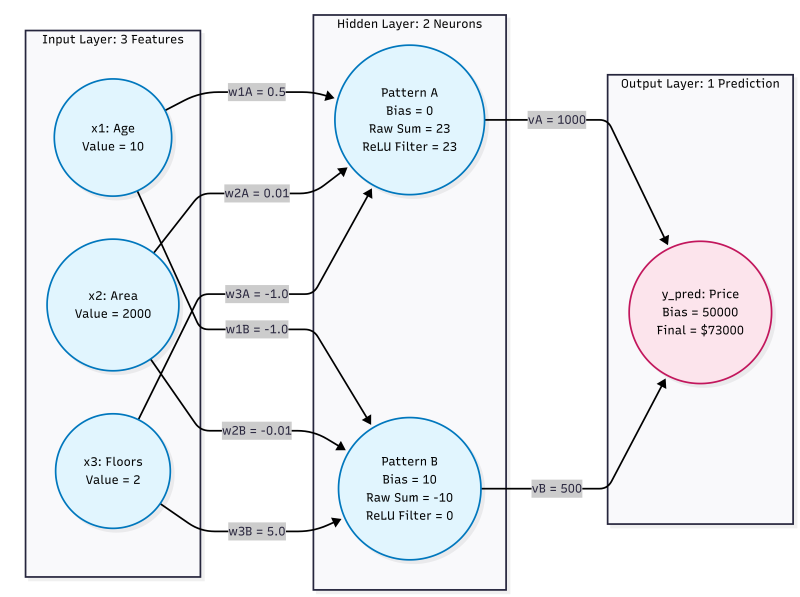

In [ ]:
""" MINI HOUSING PRICE PREDICTION USING NEURAL NETWORK DEFINED BY torch.nn """
import torch
import torch.nn as nn

# Custom OOP Model to predict the housing price using 3 example house
class HousePriceModel(nn.Module):
    # Constructor to initialize the model
    def __init__(self):
        # Call the parent constructor to create the dictionaries (_modules, _parameters)
        super().__init__()
        # Create the layers
        self.hidden_layer_0 = nn.Linear(in_features=3, out_features=2)
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(in_features=2, out_features=1)

    # Forward pass
    def forward(self, entries):
        entries = self.hidden_layer_0(entries)
        entries = self.relu(entries)
        entries = self.output_layer(entries)
        return entries

# Houses (Age, Area, Floors)
entries = torch.tensor([
    [10.0, 2000.0, 2.0],
    [15.0, 1500.0, 1.0],
    [20.0, 3000.0, 2.0]
])
entries = entries / entries.max()
# House Prices
target_prices = torch.tensor([
    [50000.0],
    [35000.0],
    [55000.0]
])
target_prices = target_prices / target_prices.max()

print(f"Entries shape: {entries.shape}")
print(f"Target shape: {target_prices.shape}")

# Instantiate the model object to construct the dictionaries and the layers we defined
model = HousePriceModel()
for name, param in model.named_parameters():
    print(f"Name: {name}, Shape: {param.shape}, Requires grad: {param.requires_grad}")

# Create a loss function object to calcuate the loss from prediction
loss_fn = nn.MSELoss()

# Create an optimzer object, pass the learnable parameters and set the learning rate
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# Defining the training loop
print("STARTING WITH THE TRAINING PROCESS")
epochs = 10000
for epoch in range(epochs + 1):
    # Forward pass
    prediction = model(entries)
    # Calculate loss
    loss = loss_fn(prediction, target_prices)
    # Clear the grad memory of the learnable parameters
    optimizer.zero_grad()
    # Backward pass
    loss.backward()
    # Optimization step
    optimizer.step()
    # Logging
    if (epoch % 1000 == 0):
        print(f"Epoch: {epoch:4d} | Loss: {loss.item():.6f}")
print("TRAINING COMPLETE")

# Final values of the parameters
final_hidden_layer_0_weights = model.hidden_layer_0.weight
final_hidden_layer_0_bias = model.hidden_layer_0.bias
print(f"Hidden layer 0 | Weights: {final_hidden_layer_0_weights} | Bias: {final_hidden_layer_0_bias}")
final_output_layer_weights = model.output_layer.weight
final_output_layer_bias = model.output_layer.bias
print(f"Hidden layer 0 | Weights: {final_output_layer_weights} | Bias: {final_output_layer_bias}")

Entries shape: torch.Size([3, 3])
Target shape: torch.Size([3, 1])
Name: hidden_layer_0.weight, Shape: torch.Size([2, 3]), Requires grad: True
Name: hidden_layer_0.bias, Shape: torch.Size([2]), Requires grad: True
Name: output_layer.weight, Shape: torch.Size([1, 2]), Requires grad: True
Name: output_layer.bias, Shape: torch.Size([1]), Requires grad: True
STARTING WITH THE TRAINING PROCESS
Epoch:    0 | Loss: 1.337878
Epoch: 1000 | Loss: 0.047846
Epoch: 2000 | Loss: 0.024312
Epoch: 3000 | Loss: 0.023883
Epoch: 4000 | Loss: 0.023875
Epoch: 5000 | Loss: 0.023875
Epoch: 6000 | Loss: 0.023875
Epoch: 7000 | Loss: 0.023875
Epoch: 8000 | Loss: 0.023875
Epoch: 9000 | Loss: 0.023875
Epoch: 10000 | Loss: 0.023875
TRAINING COMPLETE
Hidden layer 0 | Weights: Parameter containing:
tensor([[ 0.3246,  0.0283,  0.3065],
        [ 0.0293, -0.5167, -0.0996]], requires_grad=True) | Bias: Parameter containing:
tensor([-0.5219,  0.2470], requires_grad=True)
Hidden layer 0 | Weights: Parameter containing:
te

### PyTorch GPU Acceleration

In [ ]:
import torch
import torch.nn as nn

In [ ]:
# DEVICE SETUP

# Device detection string
device_string = "cuda" if torch.cuda.is_available() else "cpu"

# Create the pytorch device object
device = torch.device(device_string)
print(f"Executing on hardward: {device}")

Executing on hardward: cuda


In [ ]:
# DEFINE THE MODEL

class MultipleLinearReg(nn.Module):
    # Constructor
    def __init__(self):
        super().__init__()
        # Single linear layer
        self.linear_layer = nn.Linear(in_features=3, out_features=1)

    # Forawrd pass fuction
    def forward(self, x):
        output = self.linear_layer(x)
        return output

In [ ]:
# ALLOCATION AND MIGRATION

# Allocate model on Host (CPU RAM)
model = MultipleLinearReg()

# Migrate model to GPU (VRAM)
model = model.to(device)
print(f"Model weights reside on: {model.linear_layer.weight.device}")

Model weights reside on: cuda:0


In [ ]:
# DEFINING THE FEATURES AND TARGETS

# Input (3 entries, 3 features each)
X_cpu = torch.tensor([
    [1.0, 2.0, 1.0],     # Row 1
    [2.0, 1.0, 3.0],     # Row 2
    [3.0, 3.0, 2.0]      # Row 3
])
# Output (target for each entries)
Y_cpu = torch.tensor([
    [8.0],
    [18.0],
    [14.0]
])
# Migrate data to GPU
X_gpu = X_cpu.to(device)
Y_gpu = Y_cpu.to(device)
print(f"Features device: {X_gpu.device}, Targets device: {Y_gpu.device}")

Features device: cuda:0, Targets device: cuda:0


In [ ]:
# LOSS AND OPTIMIZER SETUP

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# TRAINING PROCESS

print("STARTING WITH THE TRAINING LOOP")
epochs = 1000
for epoch in range(epochs + 1):
    # Forward pass (prediction) (Executes in GPU VRAM)
    predictions = model(X_gpu)
    # Forward pass (loss) (Executes in GPU VRAM)
    loss = loss_fn(predictions, Y_gpu)
    # Clear old grad data (Executes in GPU VRAM)
    optimizer.zero_grad()
    # Backward pass (gradient calculation) (Executes in GPU VRAM)
    loss.backward()
    # Optimize (Executes in GPU VRAM)
    optimizer.step()
    # Logging
    if (epoch % 100 == 0):
        print(f"Epoch: {epoch} | Loss: {loss.item():.4f}")
print("TRAINING COMPLETE")


STARTING WITH THE TRAINING LOOP
Epoch: 0 | Loss: 166.5433
Epoch: 100 | Loss: 0.3942
Epoch: 200 | Loss: 0.1327
Epoch: 300 | Loss: 0.0663
Epoch: 400 | Loss: 0.0337
Epoch: 500 | Loss: 0.0171
Epoch: 600 | Loss: 0.0087
Epoch: 700 | Loss: 0.0044
Epoch: 800 | Loss: 0.0023
Epoch: 900 | Loss: 0.0011
Epoch: 1000 | Loss: 0.0006
TRAINING COMPLETE


### Model Trainig Checkpoints (saving training state)

#### Simulating a training save checkpoint

In [ ]:
import torch
import torch.nn as nn

In [ ]:
# Model class
class MultipleLinearRegression1(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer = nn.Linear(in_features=3, out_features=1)

    def forward(self, x):
        output = self.linear_layer(x)
        return output

# Instantiating and allocating our model
model = MultipleLinearRegression1()
print(f"Default weights of the original model: \n", model.linear_layer.weight)

Default weights of the original model: 
 Parameter containing:
tensor([[-0.3283, -0.3531,  0.5712]], requires_grad=True)


In [ ]:
# Defining the optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# Some training CONFGI and the LOOP

In [ ]:
# TRAINING STATE SAVE SIMULATION

# Sample epoch and loss for the simulation
current_epoch = 50
current_loss = 0.45

# Constructing dictionary checkpoint to save at a specific checkpoint using .state_dict()
# eg. save training state every 1000 epochs inside the training loop
checkpoint = {
    "epoch": current_epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": current_loss
}

# SERIALIZE (convert to byte streams) and WRITE to disk
file_path = "mlr1_model_checkpoint.pth"
torch.save(checkpoint, file_path)

print(f"Checkpoint saved to disk at: {file_path}")

Checkpoint saved to disk at: mlr1_model_checkpoint.pth


In [ ]:
# SAVED TRAINING STATE LOADING SIMULATION

# Allocate new model object (currently have random default values will be replaced by the saved values)
recovery_model = MultipleLinearRegression1()
recovery_optimizer = torch.optim.SGD(recovery_model.parameters(), lr=0.01)
print(f"Default random weight of new model: {recovery_model.linear_layer.weight}")

# DESERIALIZE (READ byte stream file from disk and load to into RAM)
loaded_checkpoint = torch.load(file_path)

# Update the model weights and optimizer history with saved training state model weights using .load_state_dict()
recovery_model.load_state_dict(loaded_checkpoint["model_state_dict"])
recovery_optimizer.load_state_dict(loaded_checkpoint["optimizer_state_dict"])

# Simulating resume from checkpoint
resumed_epoch = loaded_checkpoint["epoch"]
resumed_loss = loaded_checkpoint["loss"]
print("Recovered training state")
print(f"Resuming at epoch: {resumed_epoch}")
print("Weights AFTER loading: \n", recovery_model.linear_layer.weight)

Default random weight of new model: Parameter containing:
tensor([[-0.4381,  0.1072,  0.4566]], requires_grad=True)
Recovered training state
Resuming at epoch: 50
Weights AFTER loading: 
 Parameter containing:
tensor([[-0.3283, -0.3531,  0.5712]], requires_grad=True)


In [ ]:
# SAVE THE MODEL TRAINING STATE TO GOOGLE DRIVE
from google.colab import drive
drive.mount("/content/drive")

file_path = "/content/drive/MyDrive/mlr1_model_checkpoint.pth"
torch.save(checkpoint, file_path)

Mounted at /content/drive
